# Plotting Notebook
Each chart is generated in a separate code cell.

In [3]:
from collections import Counter
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import average_precision_score, auc, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from sklearn.svm import LinearSVC
from wordcloud import WordCloud

HERE = Path.cwd().resolve()
if (HERE / 'src').exists():
    sys.path.insert(0, str(HERE / 'src'))
elif HERE.name == 'src':
    sys.path.insert(0, str(HERE))

from evaluate import split_data
from intent_classifier import load_data

ROOT = HERE if (HERE / 'data').exists() else HERE.parent
DATA_DIR = ROOT / 'data'
REPORTS_DIR = ROOT / 'reports'

In [13]:
def read_json(path: Path):
    with path.open('r', encoding='utf-8') as handle:
        return json.load(handle)


def latest_summary_path() -> Path:
    run_dirs = [path for path in REPORTS_DIR.glob('run_*') if path.is_dir()]
    if not run_dirs:
        raise FileNotFoundError('No report run directory found under reports/. Run evaluate.py first.')
    run_dirs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    summary_path = run_dirs[0] / 'summary.json'
    if not summary_path.exists():
        raise FileNotFoundError(f'Missing summary file: {summary_path}')
    return summary_path


def compute_roc_pr_curves(texts, labels, selected_c=10.0, seed=42):
    split = split_data(texts, labels, seed=seed)

    train_val_texts = split['train_texts'] + split['val_texts']
    train_val_labels = split['train_labels'] + split['val_labels']

    vectorizer = TfidfVectorizer()
    x_train_val = vectorizer.fit_transform(train_val_texts)
    x_test = vectorizer.transform(split['test_texts'])

    model = LinearSVC(C=selected_c, max_iter=5000)
    model.fit(x_train_val, train_val_labels)
    scores = model.decision_function(x_test)

    label_order = sorted(set(labels))
    y_true_bin = label_binarize(split['test_labels'], classes=label_order)

    if scores.ndim == 1:
        scores = np.vstack([-scores, scores]).T

    macro_roc_auc = roc_auc_score(y_true_bin, scores, average='macro', multi_class='ovr')
    macro_avg_precision = average_precision_score(y_true_bin, scores, average='macro')

    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), scores.ravel())
    precision, recall, _ = precision_recall_curve(y_true_bin.ravel(), scores.ravel())

    return {
        'macro_roc_auc': float(macro_roc_auc),
        'macro_pr_auc': float(macro_avg_precision),
        'roc_curve': {'fpr': fpr.tolist(), 'tpr': tpr.tolist(), 'auc': float(auc(fpr, tpr))},
        'pr_curve': {'recall': recall.tolist(), 'precision': precision.tolist()},
    }

In [14]:
summary_path = latest_summary_path()
run_dir = summary_path.parent

summary = read_json(summary_path)
intent_summary = summary['intent']
e2e_summary = summary['e2e']
ner_summary = summary['ner']
e2e_confusion = read_json(run_dir / 'e2e' / 'e2e_confusion_matrix.json')

intent_texts, intent_labels = load_data(DATA_DIR / 'intent_dataset.json')
intent_samples = [{'text': text, 'intent': intent} for text, intent in zip(intent_texts, intent_labels)]

e2e_conf_matrix = np.array(e2e_confusion['counts'])
e2e_total = int(e2e_conf_matrix.sum())
e2e_intent_mismatch_count = int(e2e_total - np.trace(e2e_conf_matrix))

aligned_stage_breakdown = dict(e2e_summary.get('stage_breakdown', {}))
aligned_stage_breakdown['intent_mismatch'] = e2e_intent_mismatch_count
aligned_stage_breakdown['success'] = e2e_total - (
    aligned_stage_breakdown.get('intent_mismatch', 0) + aligned_stage_breakdown.get('entity_mismatch', 0)
)
e2e_summary['stage_breakdown'] = aligned_stage_breakdown

selected_c = float(intent_summary['model_results']['linear_svm']['best_params']['C'])
roc_pr = compute_roc_pr_curves(intent_texts, intent_labels, selected_c=selected_c, seed=summary['seed'])

print('Data prepared. Ready to plot.')

Data prepared. Ready to plot.


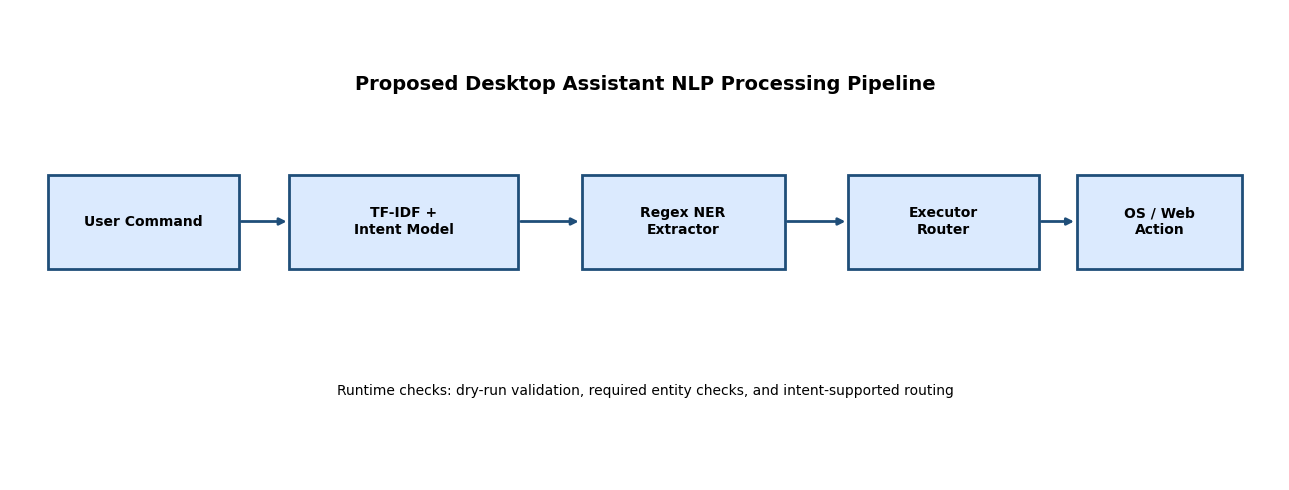

In [15]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.axis('off')

boxes = [
    (0.03, 0.45, 0.15, 0.2, 'User Command'),
    (0.22, 0.45, 0.18, 0.2, 'TF-IDF +\nIntent Model'),
    (0.45, 0.45, 0.16, 0.2, 'Regex NER\nExtractor'),
    (0.66, 0.45, 0.15, 0.2, 'Executor\nRouter'),
    (0.84, 0.45, 0.13, 0.2, 'OS / Web\nAction'),
]

for x, y, w, h, label in boxes:
    rect = plt.Rectangle((x, y), w, h, edgecolor='#1f4e79', facecolor='#dbeafe', linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w / 2, y + h / 2, label, ha='center', va='center', fontsize=10, fontweight='bold')

arrow_y = 0.55
for start_x, end_x in [(0.18, 0.22), (0.40, 0.45), (0.61, 0.66), (0.81, 0.84)]:
    ax.annotate('', xy=(end_x, arrow_y), xytext=(start_x, arrow_y), arrowprops=dict(arrowstyle='-|>', lw=2, color='#1f4e79'))

ax.text(0.5, 0.83, 'Proposed Desktop Assistant NLP Processing Pipeline', ha='center', fontsize=14, fontweight='bold')
ax.text(0.5, 0.18, 'Runtime checks: dry-run validation, required entity checks, and intent-supported routing', ha='center', fontsize=10)
fig.tight_layout()
plt.show()

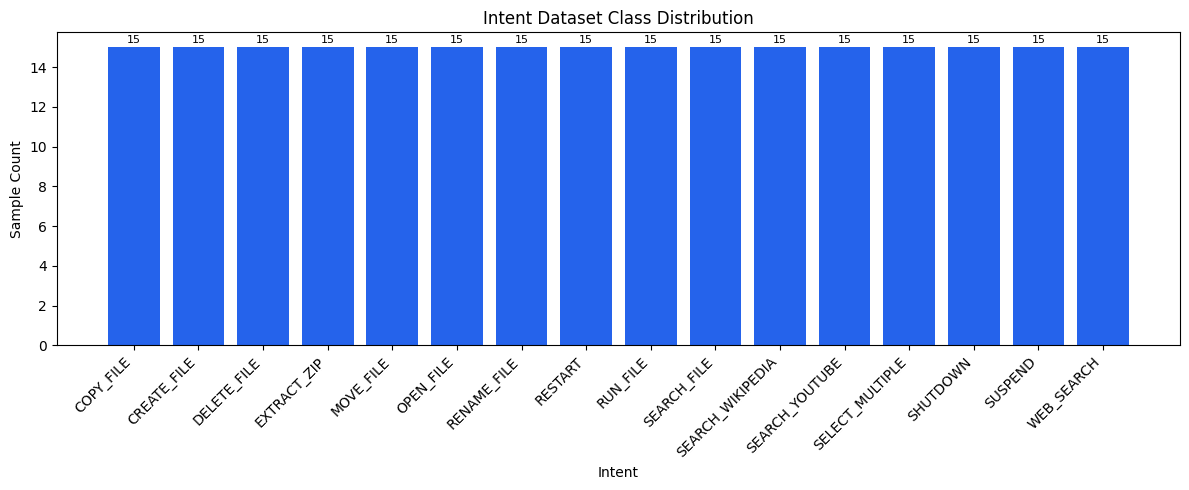

In [16]:
counts = Counter(item['intent'] for item in intent_samples)
labels = sorted(counts)
values = [counts[label] for label in labels]
positions = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(positions, values, color='#2563eb')
ax.set_title('Intent Dataset Class Distribution')
ax.set_xlabel('Intent')
ax.set_ylabel('Sample Count')
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45, ha='right')

for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.2, str(value), ha='center', fontsize=8)

fig.tight_layout()
plt.show()

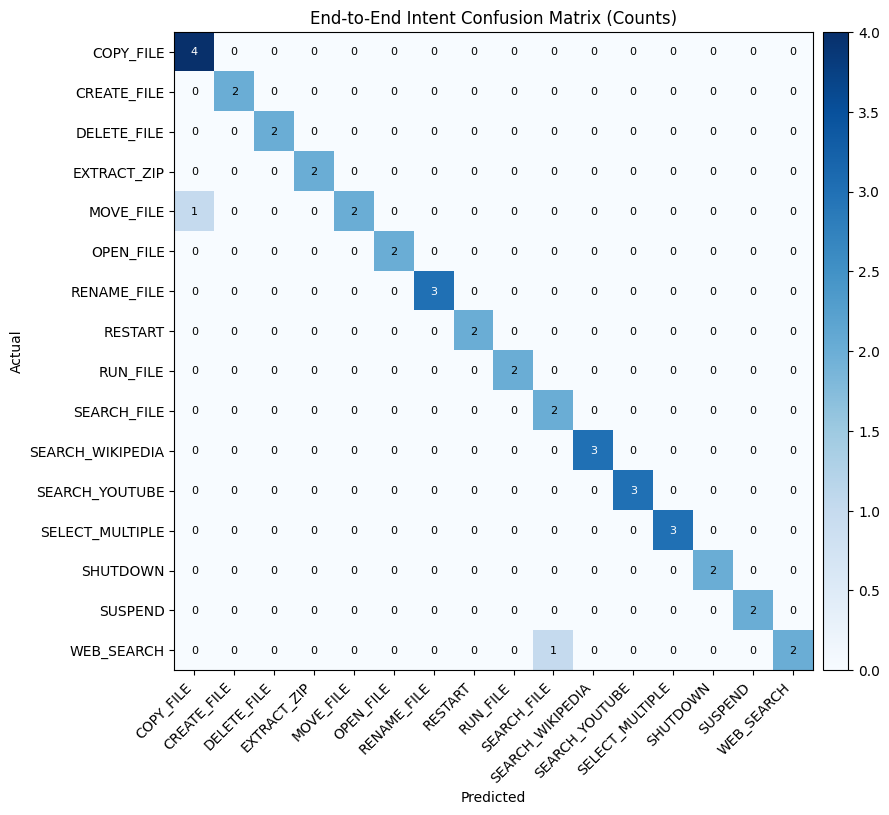

In [17]:
matrix = np.array(e2e_confusion['counts'])
labels = e2e_confusion['labels']
fig_size = max(9, int(len(labels) * 0.6))

fig, ax = plt.subplots(figsize=(fig_size, fig_size))
image = ax.imshow(matrix, cmap='Blues', aspect='equal')

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='4%', pad=0.1)
fig.colorbar(image, cax=cax)

axis_positions = np.arange(len(labels))
ax.set_xticks(axis_positions)
ax.set_yticks(axis_positions)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('End-to-End Intent Confusion Matrix (Counts)')

threshold = matrix.max() * 0.55 if matrix.max() > 0 else 0.0
for row_idx in range(matrix.shape[0]):
    for col_idx in range(matrix.shape[1]):
        value = int(matrix[row_idx, col_idx])
        color = 'white' if matrix[row_idx, col_idx] >= threshold else 'black'
        ax.text(col_idx, row_idx, str(value), ha='center', va='center', fontsize=8, color=color)

fig.tight_layout()
plt.show()

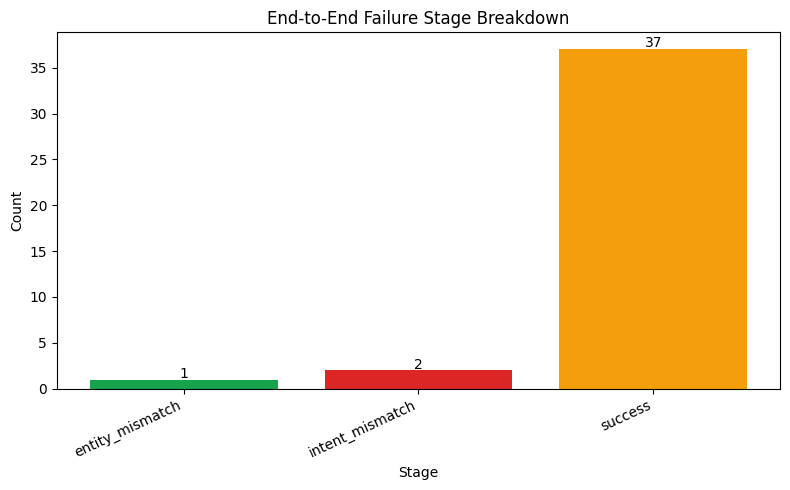

In [18]:
stage_breakdown = e2e_summary['stage_breakdown']
labels = list(stage_breakdown.keys())
values = list(stage_breakdown.values())
positions = np.arange(len(labels))

palette = ['#16a34a', '#dc2626', '#f59e0b', '#2563eb', '#9333ea']
colors = [palette[idx % len(palette)] for idx in range(len(labels))]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(positions, values, color=colors)
ax.set_title('End-to-End Failure Stage Breakdown')
ax.set_xlabel('Stage')
ax.set_ylabel('Count')
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=25, ha='right')

for idx, value in zip(positions, values):
    ax.text(idx, value + 0.2, str(value), ha='center')

fig.tight_layout()
plt.show()

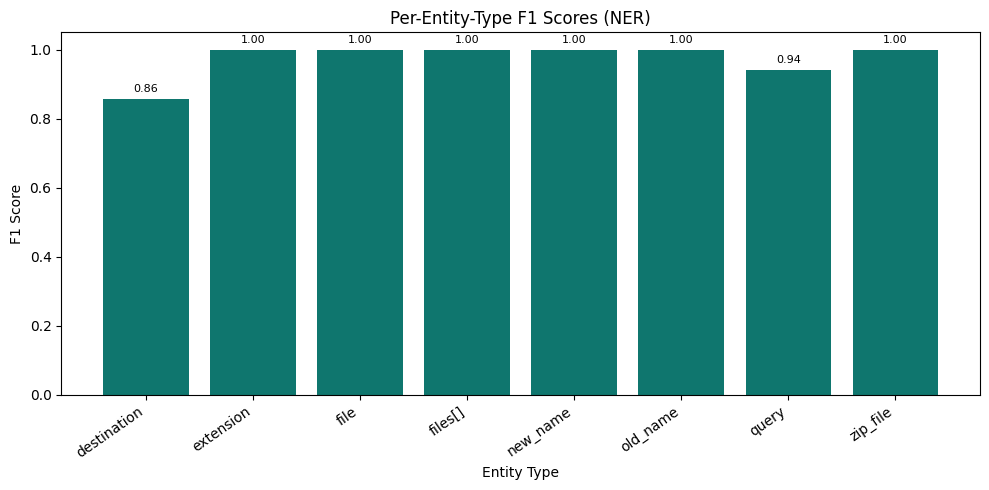

In [19]:
rows = ner_summary.get('per_entity_type', [])
labels = [row['entity_type'] for row in rows]
f1_values = [row['f1'] for row in rows]

fig, ax = plt.subplots(figsize=(10, 5))
if not labels:
    ax.text(0.5, 0.5, 'No per-entity-type data available.', ha='center', va='center')
    ax.axis('off')
else:
    positions = np.arange(len(labels))
    ax.bar(positions, f1_values, color='#0f766e')
    ax.set_ylim(0.0, 1.05)
    ax.set_title('Per-Entity-Type F1 Scores (NER)')
    ax.set_xlabel('Entity Type')
    ax.set_ylabel('F1 Score')
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=35, ha='right')

    for idx, value in zip(positions, f1_values):
        ax.text(idx, value + 0.02, f'{value:.2f}', ha='center', fontsize=8)

fig.tight_layout()
plt.show()

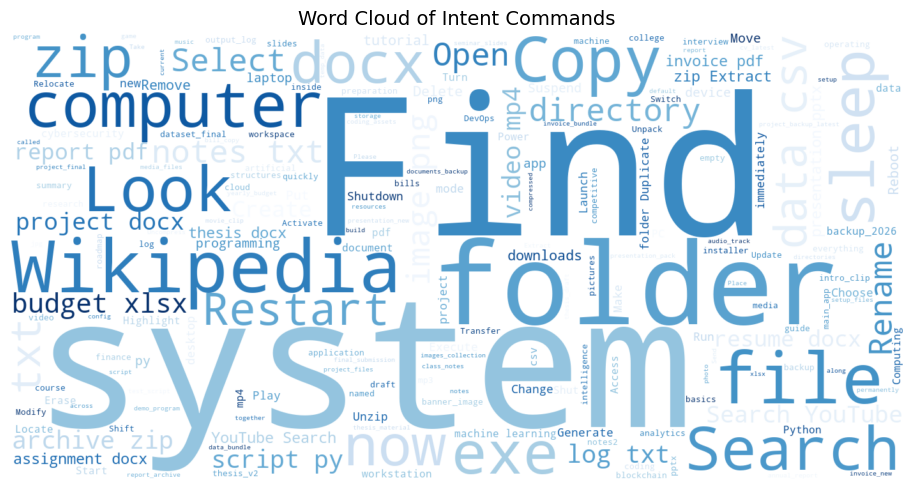

In [ ]:
corpus = ' '.join(item['text'] for item in intent_samples)
cloud = WordCloud(width=1400, height=700, background_color='white', colormap='Blues').generate(corpus)
fig, ax = plt.subplots(figsize=(11, 5))
ax.imshow(cloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud of Intent Commands', fontsize=14)
fig.tight_layout()
plt.show()

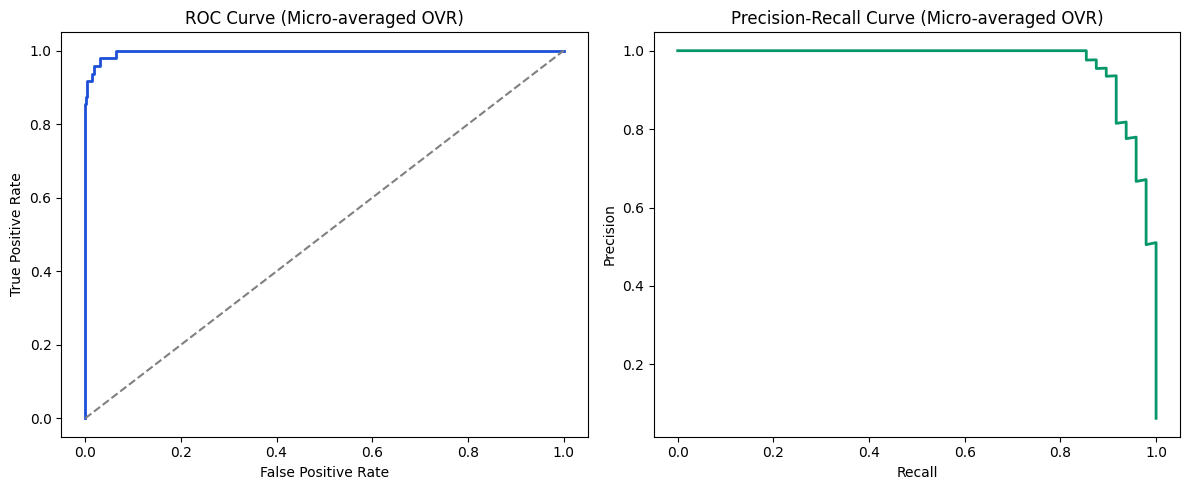

In [ ]:
fpr = np.array(roc_pr['roc_curve']['fpr'])
tpr = np.array(roc_pr['roc_curve']['tpr'])
recall = np.array(roc_pr['pr_curve']['recall'])
precision = np.array(roc_pr['pr_curve']['precision'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color='#1d4ed8', linewidth=2)
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title('ROC Curve (Micro-averaged OVR)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')

axes[1].plot(recall, precision, color='#059669', linewidth=2)
axes[1].set_title('Precision-Recall Curve (Micro-averaged OVR)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')

fig.tight_layout()
plt.show()